# Frequency Space Is Where Linear Operators Become Diagonal

One idea, two engineering problems. A linear, translation-invariant
operator -- $\partial/\partial x$ acting on a rod's temperature, or an RC
circuit acting on a voltage signal -- is hard to solve directly because
neighboring points/times are coupled. Fourier-transform the problem and
that coupling vanishes: every frequency component evolves **independently**,
governed by nothing more than a single multiply. This is exactly the same
trick as diagonalizing a matrix in its eigenbasis (`dgs.band_theory`'s
Bloch modes are the crystal-momentum version of the same idea).

This notebook runs the trick twice, using today's two new modules:
1. `dgs.heat_equation_fourier` -- the heat equation as a PDE in frequency space
2. `dgs.lti_systems` -- an RC filter's impulse/step/frequency response

Each is cross-checked against at least one independent method (not just
internal consistency).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from dgs import heat_equation_fourier as heq
from dgs import lti_systems as lti

## 1. The heat equation, transformed into frequency space

$$\frac{\partial T}{\partial t}=\alpha\frac{\partial^2 T}{\partial x^2}
\quad\xrightarrow{\ \text{Fourier transform in }x\ }\quad
\frac{d\hat T(k,t)}{dt}=-\alpha k^2\hat T(k,t)$$

The spatial derivative $\partial^2/\partial x^2$, which couples every point
to its neighbors, becomes multiplication by $-k^2$ -- no coupling left. Each
wavenumber $k$ just decays exponentially at its own rate $\alpha k^2$: sharp
(high-$k$) features smooth out fastest, exactly what "heat spreads out and
smooths sharp edges" means, made literal.

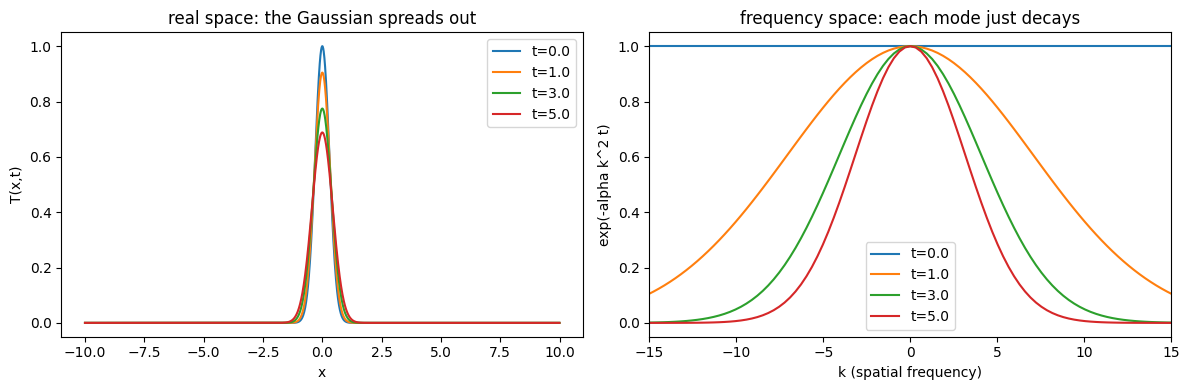

High-k (sharp) features are hit hardest:
  k=1  decay at t=5: 0.9512
  k=10 decay at t=5: 0.006738


In [2]:
alpha = 0.01
sigma0 = 0.3
L, n = 20.0, 2048
x = np.linspace(-L/2, L/2, n, endpoint=False)
dx = x[1] - x[0]

T0 = heq.heat_kernel_gaussian(x, 0.0, alpha, sigma0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for t in (0.0, 1.0, 3.0, 5.0):
    T_t = heq.heat_kernel_gaussian(x, t, alpha, sigma0)
    axes[0].plot(x, T_t, label=f"t={t}")
axes[0].set_xlabel("x"); axes[0].set_ylabel("T(x,t)"); axes[0].legend()
axes[0].set_title("real space: the Gaussian spreads out")

k = 2*np.pi*np.fft.fftshift(np.fft.fftfreq(n, d=dx))
for t in (0.0, 1.0, 3.0, 5.0):
    decay = np.fft.fftshift(heq.fourier_mode_decay(2*np.pi*np.fft.fftfreq(n, d=dx), alpha, t))
    axes[1].plot(k, decay, label=f"t={t}")
axes[1].set_xlim(-15, 15)
axes[1].set_xlabel("k (spatial frequency)"); axes[1].set_ylabel("exp(-alpha k^2 t)")
axes[1].legend(); axes[1].set_title("frequency space: each mode just decays")
plt.tight_layout(); plt.show()

print("High-k (sharp) features are hit hardest:")
print(f"  k=1  decay at t=5: {heq.fourier_mode_decay(1.0, alpha, 5.0):.4f}")
print(f"  k=10 decay at t=5: {heq.fourier_mode_decay(10.0, alpha, 5.0):.6f}")

### Cross-check: Fourier-space solution vs. an independent finite-difference solver

If the frequency-space method is right, it has to agree with a completely
different, real-space-only numerical method (explicit FTCS time-stepping)
that never transforms anything.

In [3]:
t_final = 5.0
T_fourier = heq.solve_heat_fourier(T0, x, alpha, t_final)
T_analytic = heq.heat_kernel_gaussian(x, t_final, alpha, sigma0)

dt = 0.4 * heq.ftcs_stability_limit(dx, alpha)
n_steps = int(round(t_final / dt))
T_fd = heq.solve_heat_finite_difference(T0, dx, dt, alpha, n_steps)

err_fourier = np.max(np.abs(T_fourier - T_analytic))
err_fd = np.max(np.abs(T_fd - T_analytic))
print(f"Fourier-space method vs analytic self-similar Gaussian: max error = {err_fourier:.3e}")
print(f"finite-difference ({n_steps} steps) vs analytic:        max error = {err_fd:.3e}")
assert err_fourier < 1e-4 and err_fd < 5e-3
print("\nThree independent methods (Fourier, finite-difference, analytic) agree.")

Fourier-space method vs analytic self-similar Gaussian: max error = 2.220e-16
finite-difference (2621 steps) vs analytic:        max error = 2.586e-05

Three independent methods (Fourier, finite-difference, analytic) agree.


## 2. An RC filter, the exact same trick applied to a circuit

An RC low-pass filter is also a linear, time-invariant operator -- this
time acting on a voltage signal in TIME rather than temperature in SPACE.
Its impulse response $h(t)=(1/RC)e^{-t/RC}$ plays the role the heat
kernel played above; its frequency response
$$H(f)=\frac{1}{1+j2\pi f RC}$$
is the exact analog of `exp(-alpha k^2 t)` -- a transfer function that
tells you, mode by mode, how much each frequency survives.

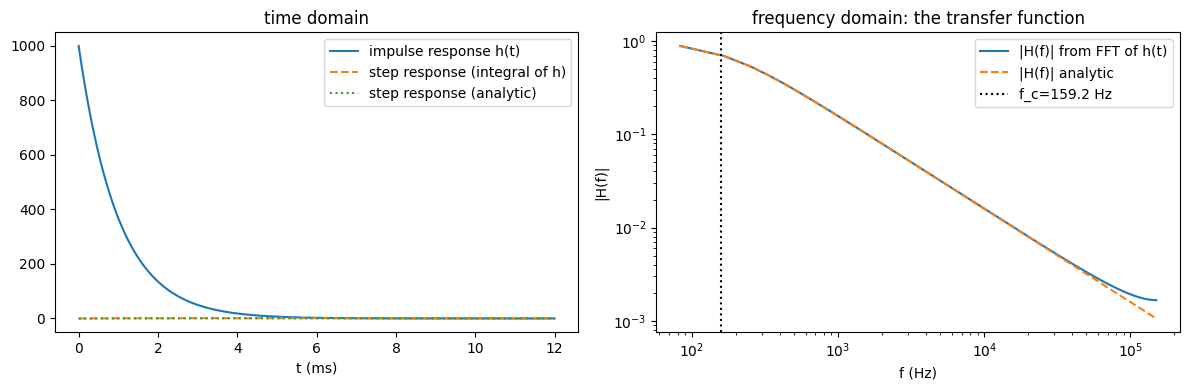

step = integral(impulse): max error vs analytic = 9.259e-07
cutoff frequency f_c = 159.2 Hz, |H(f_c)| = 0.7071 (expect 1/sqrt(2) = 0.7071)


In [4]:
R, C = 1.0e3, 1.0e-6
tau = R*C
dt_t = tau/300.0
t = np.arange(0, 12*tau, dt_t)

h = lti.impulse_response_rc(t, R, C)
s_numeric = lti.step_response_from_impulse(t, h)
s_analytic = lti.step_response_rc_analytic(t, R, C)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t*1e3, h, label="impulse response h(t)")
axes[0].plot(t*1e3, s_numeric, '--', label="step response (integral of h)")
axes[0].plot(t*1e3, s_analytic, ':', label="step response (analytic)")
axes[0].set_xlabel("t (ms)"); axes[0].legend(); axes[0].set_title("time domain")

freqs, H_numeric = lti.frequency_response_from_impulse(h, dt_t)
H_analytic = lti.transfer_function_rc(freqs, R, C)
f_c = lti.cutoff_frequency_rc(R, C)
axes[1].loglog(freqs[1:], np.abs(H_numeric[1:]), label="|H(f)| from FFT of h(t)")
axes[1].loglog(freqs[1:], np.abs(H_analytic[1:]), '--', label="|H(f)| analytic")
axes[1].axvline(f_c, color='k', linestyle=':', label=f"f_c={f_c:.1f} Hz")
axes[1].set_xlabel("f (Hz)"); axes[1].set_ylabel("|H(f)|"); axes[1].legend()
axes[1].set_title("frequency domain: the transfer function")
plt.tight_layout(); plt.show()

max_err = np.max(np.abs(s_numeric - s_analytic))
print(f"step = integral(impulse): max error vs analytic = {max_err:.3e}")
print(f"cutoff frequency f_c = {f_c:.1f} Hz, |H(f_c)| = {abs(lti.transfer_function_rc(f_c,R,C)):.4f} "
      f"(expect 1/sqrt(2) = {1/np.sqrt(2):.4f})")
assert max_err < 1e-3

## The same picture, twice

|                         | Heat equation                     | RC filter                         |
|-------------------------|------------------------------------|------------------------------------|
| domain                  | space $x$                          | time $t$                           |
| operator                | $\partial^2/\partial x^2$          | the RC circuit                     |
| transform variable      | wavenumber $k$                     | frequency $f$                      |
| per-mode response       | $e^{-\alpha k^2 t}$ (Gaussian roll-off) | $1/(1+j2\pi fRC)$ (1-pole roll-off) |
| what decays fastest     | sharp spatial features (high $k$)  | fast signal changes (high $f$)     |

Neither system can be solved point-by-point/instant-by-instant without
tracking every neighbor's influence -- until you transform into the
eigenbasis of the operator, where each mode stops talking to the others
and you're left with one-line equations. That's the entire content of
"transformed into frequency space": not a computational trick, but a
change of basis that happens to diagonalize the physics.